# Optimizer Benchmarking — UH FEL Beamline

Compares **gradient-descent** (scipy via `beamOptimizer`) on three scenarios derived from
the UH linac. Both **FELsim** (Python transfer matrices) and **COSY Infinity** (internal FIT blocks)
are used. Statistical convergence is analysed over `N_RUNS` random restarts: results are shown
as **mean ± 1σ RMS** bands, not individual traces.

| # | Scenario | Variables | Key objectives |
|---|---|---|---|
| A | Doublet (2 quads) | idx 1, 3 | α_x=α_y=0 at el. 8–9 |
| B | 11-Stage sequential (all 26 quads) | stage-by-stage | α/dispersion/envelope per stage |
| C | Combined ~11-parameter (IP+UND) | quads 56,58,61,63,76,78,80,87,93,95,97 | IP spot + UND β matching |

**Aesthetic target:** publication-quality figures inspired by the reference figures in
`backend/Figures Eremey/`. All plotting uses `EvolutionPlotter`, `ebeam.plotXYZ` and custom
statistical convergence plots.

---
**Beam:** 40 MeV electrons · 1000 particles · εₙ=8 π·mm·mrad · σ=0.8 mm · chirp h=5×10⁹ s⁻¹


In [11]:
%load_ext autotime

# ── 0. Imports & path setup ─────────────────────────────────────────
import sys, os, copy, time, warnings
# sys.path.insert(0, "/home/niels/FELsim_clone/backend")
CURRENT_DIR = os.getcwd()
BACKEND_DIR = CURRENT_DIR if os.path.basename(CURRENT_DIR) == "backend" else os.path.abspath(os.path.join(CURRENT_DIR, ".."))
sys.path.insert(0, BACKEND_DIR)
os.makedirs(os.path.join(CURRENT_DIR, "../results"), exist_ok=True)


import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from evolutionPlotter import EvolutionPlotter
from felsimAdapter import FELsimAdapter

# ── Shared constants ─────────────────────────────────────────────────
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
EXCEL_PATH  = os.path.abspath(os.path.join(CURRENT_DIR, "../../beam_excel/Beamline_elements_3.xlsx"))


BEAM_ENERGY    = 40.0    # MeV
N_PARTICLES    = 1000
SEED           = 42
CURRENT_BOUNDS = (0.01, 10.0)   # A  (lower bound > 0)

# ── Relativistic factors ─────────────────────────────────────────────
relat = lattice(1, fringeType=None)
relat.setE(E=BEAM_ENERGY)
GAMMA_REL = relat.gamma
BETA_REL  = relat.beta
NORM      = GAMMA_REL * BETA_REL

# ── Undulator matching targets (MkV FEL, K=1.2, λ_u=2.3 cm) ─────────
K        = 1.2
LAMBDA_U = 2.3e-2   # m
BETA_YM  = GAMMA_REL / (K * 2 * np.pi / LAMBDA_U)   # matched β_y at UND entrance
BETA_XM  = 1.4       # m  — matched β_x at UND entrance
ALPHA_XM = 0.47      # — Courant-Snyder α_x at UND entrance
ALPHA_YM = 0.0       # — Courant-Snyder α_y at UND entrance

print(f"γ = {GAMMA_REL:.4f},  β = {BETA_REL:.6f},  βγ = {NORM:.4f}")
print(f"Matched β_ym = {BETA_YM:.4f} m   (K={K}, λ_u={LAMBDA_U*100:.1f} cm)")
print(f"Matched β_xm = {BETA_XM:.4f} m,  α_xm = {ALPHA_XM:.4f},  α_ym = {ALPHA_YM:.4f}")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
γ = 79.2794,  β = 0.999920,  βγ = 79.2731
Matched β_ym = 0.2418 m   (K=1.2, λ_u=2.3 cm)
Matched β_xm = 1.4000 m,  α_xm = 0.4700,  α_ym = 0.0000
time: 0 ns (started: 2026-05-18 16:13:06 -10:00)


## 1 — Beam Distribution
Physics-based 6D Gaussian matching the UH linac reference parameters.


In [12]:
%load_ext autotime

# ── Beam parameters ─────────────────────────────────────────────────
epsilon_n         = 8.0      # π·mm·mrad  normalised emittance
x_std             = 0.8      # mm
y_std             = 0.8      # mm
f_RF              = 2856e6   # Hz
bunch_spread_ps   = 2.0      # ps
energy_spread_pct = 0.5      # %
h                 = 5e9      # 1/s  chirp

epsilon     = epsilon_n / NORM
x_prime_std = epsilon / x_std
y_prime_std = epsilon / y_std
tof_std     = bunch_spread_ps * 1e-9 * f_RF
energy_std  = energy_spread_pct * 10

ebeam_obj = ebeam_class()
PARTICLES = ebeam_obj.gen_6d_gaussian(
    0,
    [x_std, x_prime_std, y_std, y_prime_std, tof_std, energy_std],
    N_PARTICLES
)
# Apply longitudinal chirp
PARTICLES[:, 5] += h * (PARTICLES[:, 4] / f_RF)

print(f"ε = {epsilon:.5f} π·mm·mrad  (geometric)")
print(f"σ_x={x_std:.2f} mm, σ_x'={x_prime_std:.5f} mrad")
print(f"σ_y={y_std:.2f} mm, σ_y'={y_prime_std:.5f} mrad")
print(f"Particles: {PARTICLES.shape}")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
ε = 0.10092 π·mm·mrad  (geometric)
σ_x=0.80 mm, σ_x'=0.12615 mrad
σ_y=0.80 mm, σ_y'=0.12615 mrad
Particles: (1000, 6)
time: 15 ms (started: 2026-05-18 16:13:06 -10:00)


## 2 — Beamline & Element Index Map
The `ExcelElements` parser produces **138 FELsim elements**. Key reference indices:
| Location | FELsim idx | z (m) | Physical meaning |
|---|---|---|---|
| End of 1st doublet region | 8–9 | ≈0.73–1.0 | First α targets |
| IP (focus) | 59 | ≈7.11 | Minimum envelope |
| UND entrance | 117 | ≈12.39 | Undulator matching |


In [13]:
%load_ext autotime

# ── Load beamline & map quad indices ───────────────────────────────
beamline_full = ExcelElements(EXCEL_PATH).create_beamline()
print(f"FELsim elements: {len(beamline_full)}")

s = 0.0
quad_info = []
for i, e in enumerate(beamline_full):
    cls = e.__class__.__name__
    L   = float(getattr(e, 'length', 0.0) or 0.0)
    if cls in ('qpfLattice', 'qpdLattice'):
        quad_info.append((i, cls, round(s, 5), round(s+L, 5),
                          round(float(getattr(e, 'current', 0) or 0), 5)))
    s += L

quad_indices = [q[0] for q in quad_info]
df_quads = pd.DataFrame(quad_info, columns=['idx','type','s_start','s_end','current_A'])
print(f"Quadrupoles: {len(quad_indices)}")
print(df_quads.to_string(index=False))

# ── Gold-standard currents from Eremey's FELsim S1 solution ─────────
FELSIM_S1_CURRENTS = {
     1: 0.8218,  3: 1.0430,
    10: 3.8834,
    16: 2.2396, 18: 4.9532, 20: 3.4258,
    27: 4.6657,
    33: 2.6942, 35: 2.6523, 37: 0.2768, 39: 0.2768, 41: 2.6523, 43: 2.6942,
    50: 4.6739,
    56: 3.1219, 58: 3.3129,
    61: 5.1775, 63: 4.0434,
    70: 4.6818,
    76: 3.9336, 78: 4.0787, 80: 0.0139,
    87: 1.3624, 93: 0.9452, 95: 2.8851, 97: 2.1921,
}
print(f"\nFELSIM_S1_CURRENTS: {len(FELSIM_S1_CURRENTS)} quadrupoles loaded")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
FELsim elements: 138
Quadrupoles: 26
 idx       type  s_start    s_end  current_A
   1 qpfLattice  0.35878  0.44768    0.88572
   3 qpdLattice  0.64453  0.73342    1.05289
  10 qpfLattice  2.03304  2.12194    3.81660
  16 qpdLattice  2.73535  2.82425    2.57981
  18 qpfLattice  2.86743  2.95633    4.56570
  20 qpdLattice  2.99951  3.08841    2.57981
  27 qpfLattice  3.55448  3.64338    4.49146
  33 qpdLattice  4.15187  4.24077    1.59614
  35 qpfLattice  4.29157  4.38047    3.08092
  37 qpdLattice  4.43127  4.52017    1.59614
  39 qpdLattice  4.93513  5.02403    1.59614
  41 qpfLattice  5.07483  5.16373    3.08092
  43 qpdLattice  5.21453  5.30343    1.59614
  50 qpfLattice  5.83098  5.91988    4.49072
  56 qpdLattice  6.36946  6.45836    2.25575
  58 qpfLattice  6.55775  6.64665    1.67186
  61 qpfLattice  7.32562  7.41452    0.02487
  63 qpdLattice  7.46992  7.55882    0.00100
  70 qpfLattice  8.10749

In [14]:
%load_ext autotime

# ── Confirm key reference positions ────────────────────────────────
s = 0.0
for i, e in enumerate(beamline_full):
    s += float(getattr(e, 'length', 0.0) or 0.0)
    if i in (8, 9, 15, 25, 32, 37, 55, 59, 92, 117):
        print(f"  el {i:3d}  {e.__class__.__name__:20s}  s_end={s:.5f} m")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
  el   8  dipole_wedge          s_end=1.80682 m
  el   9  driftLattice          s_end=2.03304 m
  el  15  driftLattice          s_end=2.73535 m
  el  25  dipole_wedge          s_end=3.34855 m
  el  32  driftLattice          s_end=4.15187 m
  el  37  qpdLattice            s_end=4.52017 m
  el  55  driftLattice          s_end=6.36946 m
  el  59  driftLattice          s_end=7.11013 m
  el  92  driftLattice          s_end=10.21208 m
  el 117  driftLattice          s_end=12.39158 m
time: 0 ns (started: 2026-05-18 16:13:07 -10:00)


## 3 — Statistical Benchmark Infrastructure

`run_benchmark()` runs the same scenario `N_RUNS` times from different random starting currents.  
`plot_stat_convergence()` plots **mean ± 1σ RMS bands** — the same visual style as Eremey's
reference convergence figures.


In [15]:
%load_ext autotime

# ── Benchmark runner ────────────────────────────────────────────────
def run_benchmark(scenario_name, beamline_slice_len, particles, seg_var, obj, bounds,
                  method, n_runs=5, seed_offset=0, jac=None, verbose=True):
    """Run beamOptimizer.calc() n_runs times from uniform-random starting currents."""
    var_names = list({seg_var[i][0] for i in seg_var})
    results   = []

    for run_i in range(n_runs):
        bl = ExcelElements(EXCEL_PATH).create_beamline()[:beamline_slice_len]
        p  = particles.copy()
        rng = np.random.default_rng(SEED + seed_offset + run_i * 997)
        sp  = {v: {"bounds": bounds[v],
                   "start": float(rng.uniform(bounds[v][0], bounds[v][1]))}
               for v in var_names}
        start_x = {v: sp[v]["start"] for v in var_names}
        obj_copy = copy.deepcopy(obj)
        opti = beamOptimizer(bl, p)
        t0   = time.perf_counter()
        try:
            res  = opti.calc(method, seg_var, sp, obj_copy,
                            printResults=True, plotProgress=False)
            wall = time.perf_counter() - t0
            results.append({
                "run": run_i+1, "method": method, "scenario": scenario_name,
                "final_mse": float(res.fun), "nfev": int(getattr(res,'nfev',len(opti.plotMSE))),
                "nit": int(getattr(res,'nit',-1)), "wall_time": round(wall,3),
                "mse_curve": list(opti.plotMSE), "success": bool(res.success),
                "start_x": start_x, "result_x": dict(zip(var_names, res.x)),
            })
        except Exception as exc:
            wall = time.perf_counter() - t0
            results.append({
                "run": run_i+1, "method": method, "scenario": scenario_name,
                "final_mse": float("nan"), "nfev": -1, "nit": -1,
                "wall_time": round(wall,3), "mse_curve": [], "success": False,
                "start_x": start_x, "result_x": {}, "error": str(exc),
            })
            if verbose: print(f"  {method} run {run_i+1} FAILED: {exc}")
            continue
        if verbose:
            print(f"  {method:22s}  run {run_i+1}/{n_runs}  "
                  f"MSE={results[-1]['final_mse']:.3e}  "
                  f"nfev={results[-1]['nfev']:4d}  t={wall:.2f}s")
    return results


def results_to_df(results_list):
    keep = ('run','method','scenario','method_tag','final_mse','nfev','nit','wall_time','success')
    return pd.DataFrame([{k: r[k] for k in keep if k in r} for r in results_list])


def plot_stat_convergence(results_by_tag, title="Convergence", figsize=None,
                          colors=None, ax=None, save_path=None):
    """Publication-quality convergence plot: mean ± 1σ shaded bands per method."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize or (7, 4.5))
    else:
        fig = ax.get_figure()

    cmap = plt.cm.get_cmap("tab10")
    if colors is None:
        colors = [cmap(i) for i in range(len(results_by_tag))]

    legend_handles = []
    for (tag, res_list), col in zip(results_by_tag.items(), colors):
        curves = [r['mse_curve'] for r in res_list if r['mse_curve']]
        if not curves:
            continue
        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
        evals   = np.arange(1, max_len + 1)
        mean = np.mean(padded, axis=0)
        std  = np.std(padded,  axis=0)
        ax.plot(evals, mean, color=col, linewidth=2.0, zorder=3)
        ax.fill_between(evals, mean - std, mean + std, color=col, alpha=0.20, zorder=2)
        n_s = sum(r.get('success', False) for r in res_list)
        n_t = len(res_list)
        legend_handles.append(
            Line2D([0],[0], color=col, linewidth=2,
                   label=f"{tag}  ({n_s}/{n_t} converged)")
        )

    ax.set_yscale('log')
    ax.set_xlabel('Function evaluations', fontsize=11)
    ax.set_ylabel('Normalised MSE',        fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=9)
    if standalone:
        fig.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
    return ax


print("Benchmark helpers loaded.")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Benchmark helpers loaded.
time: 16 ms (started: 2026-05-18 16:13:07 -10:00)


---
## 4 — Scenario A: Doublet (2 quadrupoles)

**Exact replication of Stage 1 from `beamline_optimization.ipynb`:**
α_x = α_y = 0 at elements 8–9 (s ≈ 0.73–1.0 m).

Simple 2D problem — validates all methods and compares FELsim vs COSY timing.


In [16]:
%load_ext autotime

# ── Scenario A — definition ─────────────────────────────────────────
A_VARS = {
    1: ["I",  "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}
A_BOUNDS      = {"I": CURRENT_BOUNDS, "I2": CURRENT_BOUNDS}
N_RUNS_A      = 5     # ← set number of random restarts here
A_BEAMLINE_LEN = 10

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B",    None),
    ("L-BFGS-B",    "2-point"),
    ("SLSQP",       "2-point"),
    ("COBYLA",      None),
]

results_A = {}
for method, jac in METHODS_A:
    tag = method + ("+jac" if jac else "")
    print(f"\n▶ Scenario A — {tag}  ({N_RUNS_A} runs)")
    res = run_benchmark("A", A_BEAMLINE_LEN, PARTICLES, A_VARS, A_OBJ, A_BOUNDS,
                        method=method, n_runs=N_RUNS_A, seed_offset=0, jac=jac)
    for r in res: r["method_tag"] = tag
    results_A[tag] = res

df_A = results_to_df([r for v in results_A.values() for r in v])
print("\n─── Scenario A Summary ───")
print(df_A.groupby('method_tag')[['final_mse','nfev','wall_time']].agg(['mean','min']).round(4))


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=7.947e-02  nfev=  32  t=7.33s
  Nelder-Mead             run 2/5  MSE=7.947e-02  nfev=  31  t=6.02s
  Nelder-Mead             run 3/5  MSE=7.947e-02  nfev=  69  t=15.07s
  Nelder-Mead             run 4/5  MSE=2.987e-02  nfev=  75  t=15.67s
  Nelder-Mead             run 5/5  MSE=1.725e-08  nfev=  99  t=21.65s

▶ Scenario A — L-BFGS-B  (5 runs)
  L-BFGS-B                run 1/5  MSE=1.186e+07  nfev=  57  t=11.96s
  L-BFGS-B                run 2/5  MSE=1.073e-12  nfev= 126  t=25.84s
  L-BFGS-B                run 3/5  MSE=4.259e-11  nfev= 111  t=24.16s
  L-BFGS-B                run 4/5  MSE=2.118e-13  nfev=  72  t=14.88s
  L-BFGS-B                run 5/5  MSE=2.149e-13  nfev=  72  t=16.95s

▶ Scenario A — L-BFGS-B+jac  (5 runs)
  L-BFGS-B                run 1/5  MSE=1.186e+07  nfev=  57  t=14.66s
  L-BFGS-B                run 2/5  M

In [17]:
%load_ext autotime

# ── Scenario A — Best optimised quadrupole currents per method ─────
print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
print("─" * 58)
for tag, res_list in results_A.items():
    valid = [r for r in res_list
             if r.get('result_x') and not np.isnan(r['final_mse'])]
    if not valid:
        print(f"  {tag:<20}  no valid run")
        continue
    best = min(valid, key=lambda r: r['final_mse'])
    I  = best['result_x'].get('I',  float('nan'))
    I2 = best['result_x'].get('I2', float('nan'))
    print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
print()
print("  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A")
# Mean best across all runs
all_valid = [r for v in results_A.values() for r in v
             if r.get('result_x') and not np.isnan(r['final_mse'])]
if all_valid:
    best_overall = min(all_valid, key=lambda r: r['final_mse'])
    print(f"\n  Overall best across all methods/runs:")
    print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
    print(f"    I={best_overall['result_x']['I']:.5f} A,  "
          f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.7254e-08     0.7424     0.5775
  L-BFGS-B               2.1179e-13     0.2827     0.2687
  L-BFGS-B+jac           2.1179e-13     0.2827     0.2687
  SLSQP+jac              5.2954e-10     0.2827     0.2687
  COBYLA                 1.0773e-05     0.7415     0.5770

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: L-BFGS-B,  MSE=2.1179e-13
    I=0.28272 A,  I2=0.26871 A
time: 15 ms (started: 2026-05-18 16:20:36 -10:00)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime


C:\Users\yilu2\AppData\Local\Temp\ipykernel_25820\1910536845.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


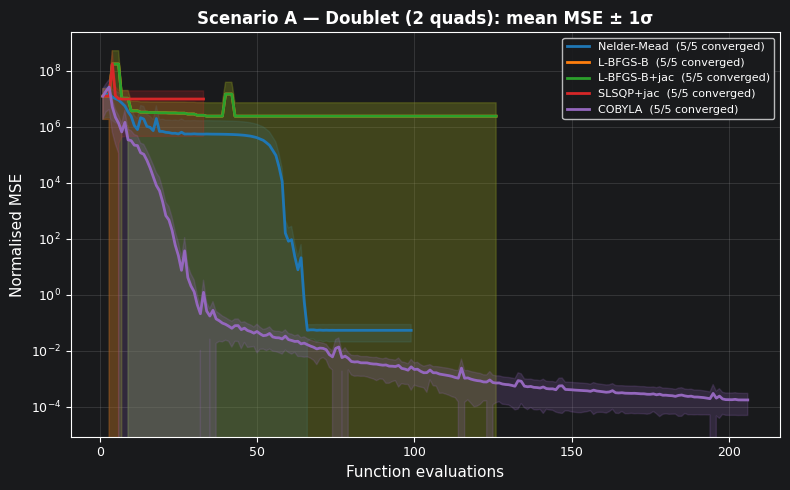

<Axes: title={'center': 'Scenario A — Doublet (2 quads): mean MSE ± 1σ'}, xlabel='Function evaluations', ylabel='Normalised MSE'>

time: 1.06 s (started: 2026-05-18 16:20:36 -10:00)


In [18]:
%load_ext autotime

# ── Scenario A — Statistical convergence plot ────────────────────────
plot_stat_convergence(
    results_A,
    title="Scenario A — Doublet (2 quads): mean MSE ± 1σ",
    figsize=(8, 5),
    # save_path="/home/niels/FELsim_clone/results/conv_A.png"
    save_path=os.path.abspath(os.path.join(CURRENT_DIR,"../results/conv_A.png"))
)

---
## 5 — Scenario A: COSY Infinity (internal FIT)

Running the same 2-quad doublet optimisation with **COSY's built-in FIT block** for direct
comparison. COSY Nalgorithm: 3=Nelder-Mead, 4=Powell, 5=Conjugate Gradient.

In [19]:
# %load_ext autotime

# # ── Scenario A — COSY FIT optimization ──────────────────────────────
# try:
#     from cosyAdapter import COSYAdapter
#     _COSY_OK = True
# except ImportError:
#     _COSY_OK = False
#     print("COSYAdapter not importable — skipping COSY cells")

# if _COSY_OK:
#     COSY_A_VARS = {1: {"current": "I1"}, 3: {"current": "I2"}}
#     COSY_A_INIT = {"I1": {"start": 1.0, "bounds": CURRENT_BOUNDS},
#                    "I2": {"start": 1.0, "bounds": CURRENT_BOUNDS}}
#     COSY_A_OBJ  = {
#         8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
#         9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
#         "optimizer_settings": {"eps": 1e-8, "Nmax": 1000, "Nalgorithm": 3}
#     }
#     cosy_sim = COSYAdapter(excel_path=EXCEL_PATH, mode='transfer_matrix')
#     t0 = time.perf_counter()
#     cosy_res_A = cosy_sim.optimize(
#         objectives=COSY_A_OBJ,
#         variables=COSY_A_VARS,
#         initial_point=COSY_A_INIT,
#         method='nelder-mead'
#     )
#     t_cosy_A = time.perf_counter() - t0
#     print(f"COSY Scenario A: success={cosy_res_A.success}  t={t_cosy_A:.2f} s")
#     if cosy_res_A.success:
#         print("  Optimised vars:", cosy_res_A.optimization_variables)
#         twiss = cosy_res_A.twiss_parameters_transfer_map
#         if twiss:
#             print(f"  β_x={twiss.get('beta_x','N/A')}  α_x={twiss.get('alpha_x','N/A')}")
#             print(f"  β_y={twiss.get('beta_y','N/A')}  α_y={twiss.get('alpha_y','N/A')}")


time: 0 ns (started: 2026-05-18 16:20:37 -10:00)


---
## 6 — Scenario B: 11-Stage Sequential Optimization (all 26 quads)

**Full replication of `beamline_optimization.ipynb` Cells 5–16.**

Each stage uses the beamline state left by the previous stage (currents persist).

| Stage | Quads | Obj. element(s) | Targets |
|---|---|---|---|
| 1 | 1, 3 | 8, 9 | α_x=α_y=0 |
| 2 | 10 | 15 | D_x=0 |
| 3 | 16, 18, 20 | 25, 26 | α_x=α_y=0 |
| 4 | 27 | 32 | D_x=0 |
| 5 | 37, 35, 33 | 37 | α_x=α_y=0, E_x=E_y=2 mm (+ mirror 39,41,43) |
| 6 | 50 | 55 | D_x=0 |
| 7 | 56, 58 | 59 | E_x=E_y=0 (IP focus) |
| 8 | 61, 63 | 68, 69 | α_x=α_y=0 |
| 9 | 70 | 75 | D_x=0 |
| 10 | 76, 78, 80 | 85, 86 | α_x=α_y=0 |
| 11 | 87, 93, 95, 97 | 92, 117 | D_x=0 at el.92 + β_x=1.4, β_y=0.24, α_x=0.47, α_y=0 at UND |


In [20]:
%load_ext autotime

# ── Scenario B — Stage definitions ──────────────────────────────────
def _v(name): return [name, "current", lambda x, _n=name: x]

STAGES_B = [
    ("Stage 1 Doublet",
     {1: _v("I"), 3: _v("I2")},
     {8: [{"measure":["x","alpha"],"goal":0,"weight":1},
          {"measure":["x","beta"],"goal":0.1,"weight":0.0}],
      9: [{"measure":["y","alpha"],"goal":0,"weight":1},
          {"measure":["y","beta"],"goal":0.1,"weight":0.5}]},
     10,
     {"I":{"bounds":CURRENT_BOUNDS,"start":1},"I2":{"bounds":CURRENT_BOUNDS,"start":1}}),
    ("Stage 2 Chrom.1",
     {10: _v("I")},
     {15: [{"measure":["x","dispersion"],"goal":0,"weight":1}]},
     16,
     {"I":{"bounds":CURRENT_BOUNDS,"start":1}}),
    ("Stage 3 Triplet1",
     {16: _v("I"), 18: _v("I2"), 20: _v("I3")},
     {25: [{"measure":["x","alpha"],"goal":0,"weight":1},
           {"measure":["x","beta"],"goal":0.1,"weight":0.5}],
      26: [{"measure":["y","alpha"],"goal":0,"weight":1},
           {"measure":["y","beta"],"goal":0.1,"weight":0.5}]},
     27,
     {"I":{"bounds":CURRENT_BOUNDS,"start":2},"I2":{"bounds":CURRENT_BOUNDS,"start":5},"I3":{"bounds":CURRENT_BOUNDS,"start":3}}),
    ("Stage 4 Chrom.2",
     {27: _v("I")},
     {32: [{"measure":["x","dispersion"],"goal":0,"weight":1}]},
     33,
     {"I":{"bounds":CURRENT_BOUNDS,"start":1}}),
    ("Stage 5 DblTriplet",
     {37: _v("I"), 35: _v("I2"), 33: _v("I3")},
     {37: [{"measure":["x","alpha"],"goal":0,"weight":1},
           {"measure":["y","alpha"],"goal":0,"weight":1},
           {"measure":["x","envelope"],"goal":2.0,"weight":1},
           {"measure":["y","envelope"],"goal":2.0,"weight":1}]},
     38,
     {"I":{"bounds":CURRENT_BOUNDS,"start":0.28},"I2":{"bounds":CURRENT_BOUNDS,"start":2.65},"I3":{"bounds":CURRENT_BOUNDS,"start":2.69}}),
    ("Stage 6 Chrom.3",
     {50: _v("I")},
     {55: [{"measure":["x","dispersion"],"goal":0,"weight":1}]},
     56,
     {"I":{"bounds":CURRENT_BOUNDS,"start":1}}),
    ("Stage 7 IP",
     {56: _v("I"), 58: _v("I2")},
     {59: [{"measure":["x","envelope"],"goal":0.0,"weight":1},
           {"measure":["y","envelope"],"goal":0.0,"weight":1}]},
     60,
     {"I":{"bounds":CURRENT_BOUNDS,"start":2},"I2":{"bounds":CURRENT_BOUNDS,"start":2}}),
    ("Stage 8 Doublet2",
     {61: _v("I"), 63: _v("I2")},
     {68: [{"measure":["x","alpha"],"goal":0,"weight":1},
           {"measure":["x","beta"],"goal":0.1,"weight":0.5}],
      69: [{"measure":["y","alpha"],"goal":0,"weight":1},
           {"measure":["y","beta"],"goal":0.1,"weight":0.5}]},
     70,
     {"I":{"bounds":CURRENT_BOUNDS,"start":2},"I2":{"bounds":CURRENT_BOUNDS,"start":2}}),
    ("Stage 9 Chrom.4",
     {70: _v("I")},
     {75: [{"measure":["x","dispersion"],"goal":0,"weight":1}]},
     76,
     {"I":{"bounds":CURRENT_BOUNDS,"start":1}}),
    ("Stage 10 Triplet3",
     {76: _v("I"), 78: _v("I2"), 80: _v("I3")},
     {85: [{"measure":["x","alpha"],"goal":0,"weight":1},
           {"measure":["x","beta"],"goal":0.1,"weight":0.5}],
      86: [{"measure":["y","alpha"],"goal":0,"weight":1},
           {"measure":["y","beta"],"goal":0.1,"weight":0.5}]},
     87,
     {"I":{"bounds":CURRENT_BOUNDS,"start":2},"I2":{"bounds":CURRENT_BOUNDS,"start":2},"I3":{"bounds":CURRENT_BOUNDS,"start":2}}),
    ("Stage 11 UND Match",
     {87: _v("Ic"), 93: _v("I"), 95: _v("I2"), 97: _v("I3")},
     {92:  [{"measure":["x","dispersion"],"goal":0,"weight":0.5}],
      117: [{"measure":["x","alpha"],"goal":ALPHA_XM,"weight":1},
            {"measure":["y","alpha"],"goal":ALPHA_YM,"weight":1},
            {"measure":["x","beta"], "goal":BETA_XM, "weight":1},
            {"measure":["y","beta"], "goal":BETA_YM, "weight":1}]},
     118,
     {"Ic":{"bounds":CURRENT_BOUNDS,"start":4},"I":{"bounds":CURRENT_BOUNDS,"start":2},
      "I2":{"bounds":CURRENT_BOUNDS,"start":2},"I3":{"bounds":CURRENT_BOUNDS,"start":2}}),
]

print(f"Defined {len(STAGES_B)} stages for Scenario B")
for i, (lbl, sv, obj, bl_len, sp) in enumerate(STAGES_B, 1):
    n_vars = len(sv); n_obj = sum(len(v) for v in obj.values())
    print(f"  {lbl:25s}  {n_vars} vars  {n_obj} obj terms  bl[:{bl_len}]")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Defined 11 stages for Scenario B
  Stage 1 Doublet            2 vars  4 obj terms  bl[:10]
  Stage 2 Chrom.1            1 vars  1 obj terms  bl[:16]
  Stage 3 Triplet1           3 vars  4 obj terms  bl[:27]
  Stage 4 Chrom.2            1 vars  1 obj terms  bl[:33]
  Stage 5 DblTriplet         3 vars  4 obj terms  bl[:38]
  Stage 6 Chrom.3            1 vars  1 obj terms  bl[:56]
  Stage 7 IP                 2 vars  2 obj terms  bl[:60]
  Stage 8 Doublet2           2 vars  4 obj terms  bl[:70]
  Stage 9 Chrom.4            1 vars  1 obj terms  bl[:76]
  Stage 10 Triplet3          3 vars  4 obj terms  bl[:87]
  Stage 11 UND Match         4 vars  5 obj terms  bl[:118]
time: 16 ms (started: 2026-05-18 16:20:37 -10:00)


In [21]:
%load_ext autotime

# ── Scenario B — N_RUNS_B statistical runs ──────────────────────────
N_RUNS_B = 3    # ← set number of full 11-stage sequence runs here
METHOD_B  = "Nelder-Mead"

print(f"Running {N_RUNS_B} full 11-stage sequences ({METHOD_B})")
stage_mse_runs    = [[] for _ in STAGES_B]
stage_nfev_runs   = [[] for _ in STAGES_B]
stage_time_runs   = [[] for _ in STAGES_B]
stage_curves_runs = [[] for _ in STAGES_B]

for run_i in range(N_RUNS_B):
    bl_run = ExcelElements(EXCEL_PATH).create_beamline()
    bl_run[0].changeBeamType("electron", BEAM_ENERGY, bl_run)
    p_run  = PARTICLES.copy()
    print(f"── Run {run_i+1}/{N_RUNS_B} ──")

    for s_i, (lbl, seg_var, obj, bl_len, fixed_sp) in enumerate(STAGES_B):
        sp       = copy.deepcopy(fixed_sp)
        obj_copy = copy.deepcopy(obj)
        bl_stage = bl_run[:bl_len]
        opti     = beamOptimizer(bl_stage, p_run.copy())
        t0       = time.perf_counter()
        try:
            res  = opti.calc(METHOD_B, seg_var, sp, obj_copy,
                             printResults=True, plotProgress=False)
            wall = time.perf_counter() - t0
            # Write optimised currents back into the full beamline
            for elem_idx, var_info in seg_var.items():
                var_name = var_info[0]
                var_idx  = opti.variablesToOptimize.index(var_name)
                setattr(bl_run[elem_idx], 'current', float(res.x[var_idx]))
            # Stage 5 mirror symmetry
            if s_i == 4:
                bl_run[43].current = bl_run[33].current
                bl_run[41].current = bl_run[35].current
                bl_run[39].current = bl_run[37].current
            stage_mse_runs[s_i].append(float(res.fun))
            stage_nfev_runs[s_i].append(int(getattr(res,'nfev',len(opti.plotMSE))))
            stage_time_runs[s_i].append(round(wall, 3))
            stage_curves_runs[s_i].append(list(opti.plotMSE))
            print(f"  {lbl:25s}  MSE={res.fun:.3e}  "
                  f"nfev={stage_nfev_runs[s_i][-1]:3d}  t={wall:.2f}s")
        except Exception as exc:
            stage_mse_runs[s_i].append(float("nan"))
            stage_nfev_runs[s_i].append(-1)
            stage_time_runs[s_i].append(0)
            stage_curves_runs[s_i].append([])
            print(f"  {lbl:25s}  FAILED: {exc}")

print("\nScenario B complete.")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Running 3 full 11-stage sequences (Nelder-Mead)
── Run 1/3 ──
  Stage 1 Doublet            MSE=1.262e-04  nfev= 68  t=14.37s
  Stage 2 Chrom.1            MSE=4.472e-14  nfev= 40  t=18.62s
  Stage 3 Triplet1           MSE=1.661e-03  nfev=600  t=496.88s
  Stage 4 Chrom.2            MSE=8.805e-14  nfev= 40  t=42.95s
  Stage 5 DblTriplet         MSE=1.517e-01  nfev=346  t=418.03s
  Stage 6 Chrom.3            MSE=1.430e-14  nfev= 40  t=76.55s
  Stage 7 IP                 MSE=3.693e-03  nfev= 76  t=137.88s
  Stage 8 Doublet2           MSE=1.071e-03  nfev=146  t=314.76s
  Stage 9 Chrom.4            MSE=1.117e-13  nfev= 40  t=94.69s
  Stage 10 Triplet3          MSE=1.461e-03  nfev=173  t=494.35s
  Stage 11 UND Match         MSE=1.978e-05  nfev=535  t=2072.27s
── Run 2/3 ──
  Stage 1 Doublet            MSE=1.262e-04  nfev= 68  t=14.53s
  Stage 2 Chrom.1            MSE=4.472e-14  nfev= 40  t=18.94s
  Stage 3 Trip

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime


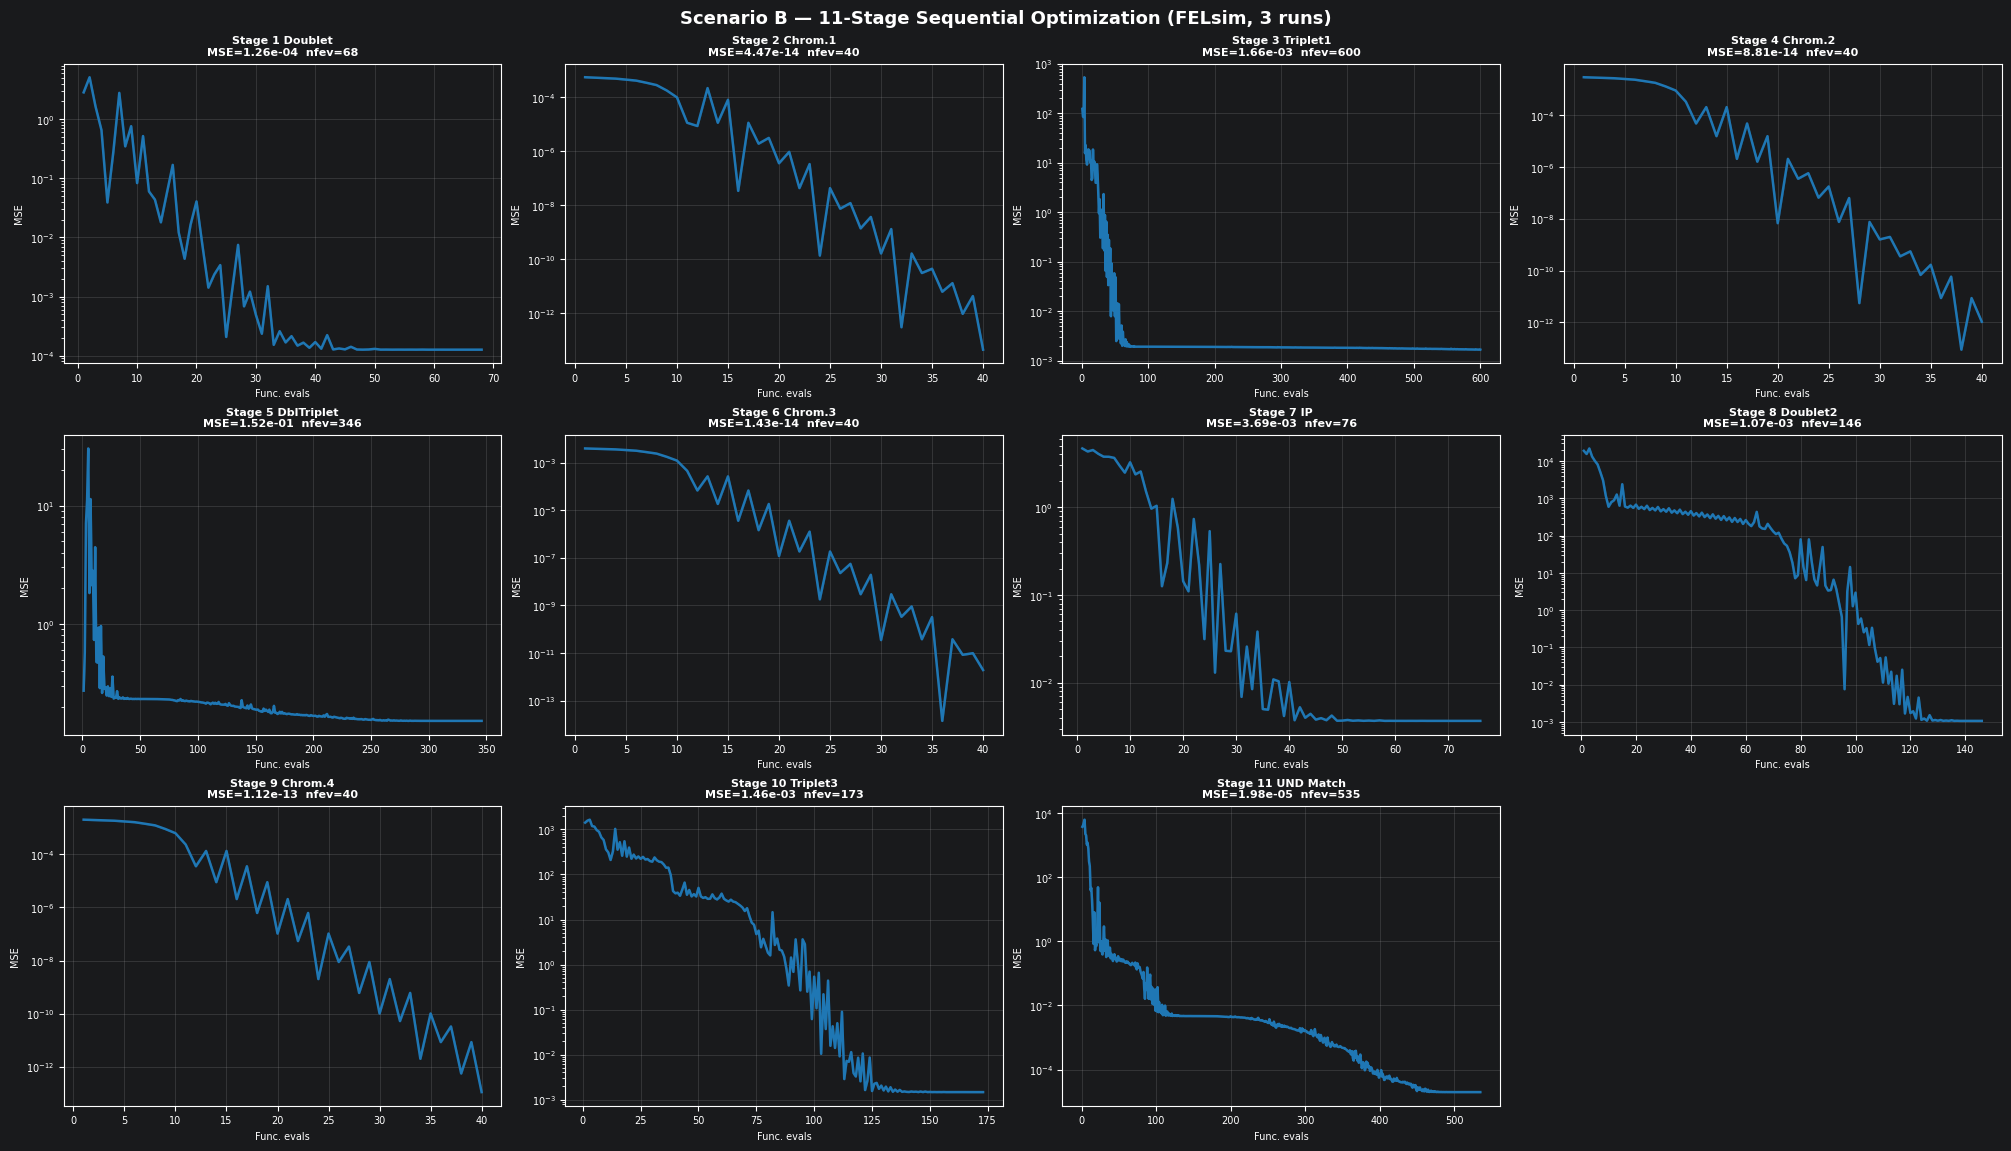

Figure saved.
time: 8.12 s (started: 2026-05-18 19:48:16 -10:00)


In [22]:
%load_ext autotime

# ── Scenario B — Per-stage convergence: mean ± 1σ grid ──────────────
n_stages = len(STAGES_B)
ncols = 4; nrows = (n_stages + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows), constrained_layout=True)
axes_flat = axes.flatten()
col = plt.cm.tab10(0)
for s_i, (lbl, *_) in enumerate(STAGES_B):
    ax = axes_flat[s_i]
    curves = [c for c in stage_curves_runs[s_i] if c]
    if curves:
        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]]*(max_len-len(c)) for c in curves])
        evals   = np.arange(1, max_len+1)
        mean = np.mean(padded, axis=0); std = np.std(padded, axis=0)
        ax.plot(evals, mean, color=col, linewidth=1.8)
        ax.fill_between(evals, mean-std, mean+std, color=col, alpha=0.2)
    mean_mse  = np.nanmean(stage_mse_runs[s_i])
    mean_nfev = np.nanmean(stage_nfev_runs[s_i])
    ax.set_title(f"{lbl}\nMSE={mean_mse:.2e}  nfev={mean_nfev:.0f}", fontsize=8, fontweight='bold')
    ax.set_yscale('log'); ax.set_xlabel('Func. evals', fontsize=7)
    ax.set_ylabel('MSE', fontsize=7); ax.tick_params(labelsize=7); ax.grid(True, alpha=0.25)
for ax in axes_flat[n_stages:]: ax.set_visible(False)
fig.suptitle(f"Scenario B — 11-Stage Sequential Optimization (FELsim, {N_RUNS_B} runs)",
             fontsize=13, fontweight='bold')
# fig.savefig("/home/niels/FELsim_clone/results/conv_B_stages.png", dpi=200, bbox_inches='tight')
fig.savefig(os.path.abspath(os.path.join(CURRENT_DIR,"../results/conv_B_stages.png")), dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [23]:
%load_ext autotime

# ── Scenario B — Summary table ───────────────────────────────────────
rows = []
for s_i, (lbl, *_) in enumerate(STAGES_B):
    msev = [v for v in stage_mse_runs[s_i] if not np.isnan(v)]
    rows.append({"stage": lbl,
                 "mean_mse":  round(np.mean(msev),  5) if msev else np.nan,
                 "min_mse":   round(np.min(msev),   5) if msev else np.nan,
                 "mean_nfev": round(np.nanmean(stage_nfev_runs[s_i]), 1),
                 "mean_time": round(np.nanmean(stage_time_runs[s_i]), 3)})
df_B_summary = pd.DataFrame(rows)
print("─── Scenario B Summary ───")
print(df_B_summary.to_string(index=False))

# ── Compare final Stage 11 result vs FELSIM_S1_CURRENTS reference ───
print("\n─── Stage 11 currents vs FELSIM_S1_CURRENTS ───")
print(f"{'Quad idx':>10}  {'Optimised':>12}  {'Reference':>12}  {'Δ':>10}")
for bl_idx in [87, 93, 95, 97]:
    opt_val = getattr(beamline_full[bl_idx], 'current', float('nan'))
    ref_val = FELSIM_S1_CURRENTS.get(bl_idx, float('nan'))
    delta   = abs(opt_val - ref_val) if not (np.isnan(opt_val) or np.isnan(ref_val)) else float('nan')
    print(f"{bl_idx:>10d}  {opt_val:>12.4f}  {ref_val:>12.4f}  {delta:>10.4f}")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
─── Scenario B Summary ───
             stage  mean_mse  min_mse  mean_nfev  mean_time
   Stage 1 Doublet   0.00013  0.00013       68.0     14.652
   Stage 2 Chrom.1   0.00000  0.00000       40.0     19.859
  Stage 3 Triplet1   0.00166  0.00166      600.0    502.529
   Stage 4 Chrom.2   0.00000  0.00000       40.0     47.916
Stage 5 DblTriplet   0.15171  0.15171      346.0    422.210
   Stage 6 Chrom.3   0.00000  0.00000       40.0     76.641
        Stage 7 IP   0.00369  0.00369       76.0    142.636
  Stage 8 Doublet2   0.00107  0.00107      146.0    313.450
   Stage 9 Chrom.4   0.00000  0.00000       40.0     94.355
 Stage 10 Triplet3   0.00146  0.00146      173.0    472.490
Stage 11 UND Match   0.00002  0.00002      535.0   2046.070

─── Stage 11 currents vs FELSIM_S1_CURRENTS ───
  Quad idx     Optimised     Reference           Δ
        87        3.8166        1.3624      2.4542
        93        

---
## 7 — Scenario B: COSY Infinity (staged FIT blocks)

`set_optimization_objectives(reset=False)` generates **multiple sequential FIT blocks** in a
single `.fox` run. This is the COSY analogue of the FELsim staged approach.  
> **Note:** COSY `MEASURE_MAP` supports only α, β, γ — dispersion stages 2,4,6,9,11 are omitted.

In [24]:
# %load_ext autotime

# # ── Scenario B — COSY staged FIT blocks via cosyOptHelper ───────────
# try:
#     from cosyOptHelper import add_stages, get_optimized_currents
#     _COSY_HELPER_OK = True
# except ImportError:
#     _COSY_HELPER_OK = False
#     print("cosyOptHelper not available — skipping")

# if _COSY_OK and _COSY_HELPER_OK:
#     cosy_stages_B = []
#     for lbl, seg_var, obj, bl_len, sp in STAGES_B:
#         stage_dict = {
#             'name': lbl,
#             'variables': {idx: var_info[0] for idx, var_info in seg_var.items()},
#             'start_point': sp,
#             'objectives': obj,
#         }
#         if lbl == "Stage 5 DblTriplet":
#             stage_dict['mirror'] = {43: 33, 41: 35, 39: 37}
#         cosy_stages_B.append(stage_dict)

#     cosy_b_sim = COSYAdapter(excel_path=EXCEL_PATH, mode='transfer_matrix')
#     native_b   = cosy_b_sim.get_native_simulator()
#     add_stages(native_b, cosy_stages_B)

#     t0 = time.perf_counter()
#     result_dict_b = native_b.run_simulation()
#     t_cosy_B      = time.perf_counter() - t0
#     print(f"COSY staged FIT: status={result_dict_b.get('status')}  t={t_cosy_B:.2f} s")

#     reader_b = native_b.analyze_results()
#     opt_currents_B = get_optimized_currents(reader_b, cosy_stages_B)
#     print(f"  Optimised currents: {opt_currents_B}")

#     twiss_b = reader_b.get_twiss_from_transfer_map()
#     print(f"  β_x={twiss_b.get('beta_x','N/A'):.4f}  α_x={twiss_b.get('alpha_x','N/A'):.4f}")
#     print(f"  β_y={twiss_b.get('beta_y','N/A'):.4f}  α_y={twiss_b.get('alpha_y','N/A'):.4f}")
# else:
#     print("COSY not available — skipping")

time: 0 ns (started: 2026-05-18 19:48:25 -10:00)


---
## 8 — Scenario C: Combined ~11-parameter, Dual Objective (IP + UND)

**~11 quadrupoles** activated simultaneously, with two simultaneous physics objectives:

1. **IP (el. 59, z≈7.11 m):** minimise transverse envelope → `E_x=E_y=0`
2. **UND entrance (el. 117, z≈12.39 m):** match Courant-Snyder →
   `β_x=1.4 m`, `β_y=β_ym≈0.2418 m`, `α_x=0.47`, `α_y=0`

Selected quads: **56, 58, 61, 63, 76, 78, 80, 87, 93, 95, 97**

In [ ]:
%load_ext autotime

# ── Scenario C definition ────────────────────────────────────────────
C_QUAD_IDX = [56, 58, 61, 63, 76, 78, 80, 87, 93, 95, 97]

C_VARS = {}
for k, idx in enumerate(C_QUAD_IDX, 1):
    C_VARS[idx] = [f"Ic{k}", "current", (lambda x, _k=k: x)]

C_OBJ = {
    59: [
        {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1.0, "scale": 1.0},
        {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1.0, "scale": 1.0},
    ],
    117: [
        {"measure": ["x", "beta"],  "goal": BETA_XM,  "weight": 1.0, "scale": BETA_XM},
        {"measure": ["y", "beta"],  "goal": BETA_YM,  "weight": 1.0, "scale": BETA_YM},
        {"measure": ["x", "alpha"], "goal": ALPHA_XM, "weight": 1.0, "scale": 1.0},
        {"measure": ["y", "alpha"], "goal": ALPHA_YM, "weight": 1.0, "scale": 1.0},
    ],
}
C_BOUNDS       = {f"Ic{k}": CURRENT_BOUNDS for k in range(1, 12)}
C_BEAMLINE_LEN = 118

print(f"Scenario C: {len(C_VARS)} variables, "
      f"{sum(len(v) for v in C_OBJ.values())} objective terms")
print(f"  Quad indices: {C_QUAD_IDX}")
print(f"  β_xm={BETA_XM:.4f} m,  β_ym={BETA_YM:.4f} m")
print(f"  α_xm={ALPHA_XM:.4f},   α_ym={ALPHA_YM:.4f}")

N_RUNS_C  = 5
METHODS_C = [
    ("Nelder-Mead", None),
    ("L-BFGS-B",    "2-point"),
    ("SLSQP",       "2-point"),
]

results_C = {}
for method, jac in METHODS_C:
    tag = method + ("+jac" if jac else "")
    print(f"\n▶ Scenario C — {tag}  ({N_RUNS_C} runs)")
    res = run_benchmark("C", C_BEAMLINE_LEN, PARTICLES, C_VARS, C_OBJ, C_BOUNDS,
                        method=method, n_runs=N_RUNS_C, seed_offset=200, jac=jac)
    for r in res: r["method_tag"] = tag
    results_C[tag] = res

df_C = results_to_df([r for v in results_C.values() for r in v])
print("\n─── Scenario C Summary ───")
print(df_C.groupby('method_tag')[['final_mse','nfev','wall_time']].agg(['mean','min']).round(4))

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Scenario C: 11 variables, 6 objective terms
  Quad indices: [56, 58, 61, 63, 76, 78, 80, 87, 93, 95, 97]
  β_xm=1.4000 m,  β_ym=0.2418 m
  α_xm=0.4700,   α_ym=0.0000

▶ Scenario C — Nelder-Mead  (5 runs)


C:\Users\yilu2\my_files\research\FELsim\backend_orig\ebeam.py:145: RuntimeWarning: invalid value encountered in sqrt
  epsilon = np.sqrt(var_disp_free * var_prime_disp_free - covar_disp_free ** 2)
C:\Users\yilu2\my_files\research\FELsim\backend_orig\ebeam.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = -covar_disp_free / epsilon
C:\Users\yilu2\my_files\research\FELsim\backend_orig\ebeam.py:148: RuntimeWarning: divide by zero encountered in scalar divide
  beta = var_disp_free / epsilon
C:\Users\yilu2\my_files\research\FELsim\backend_orig\ebeam.py:149: RuntimeWarning: divide by zero encountered in scalar divide
  gamma = var_prime_disp_free / epsilon
C:\Users\yilu2\my_files\research\FELsim\backend_orig\ebeam.py:162: RuntimeWarning: invalid value encountered in scalar subtract
  phi_rad = 0.5 * np.arctan2(2 * alpha, gamma - beta)


In [ ]:
%load_ext autotime

# ── Scenario C — Statistical convergence plot ────────────────────────
plot_stat_convergence(
    results_C,
    title=f"Scenario C — Dual-objective IP+UND (11 quads): mean MSE ± 1σ",
    figsize=(9, 5),
    # save_path="/home/niels/FELsim_clone/results/conv_C.png"
    save_path=os.path.abspath(os.path.join(CURRENT_DIR,"../results/conv_C.png"))
)


In [ ]:
# %load_ext autotime

# # ── Scenario C — COSY dual-objective FIT via cosyOptHelper ───────────
# # Two FIT blocks: IP envelope minimisation then full UND Twiss matching.
# if _COSY_OK and _COSY_HELPER_OK:
#     cosy_stages_C = [
#         {
#             'name': 'IP Doublet',
#             'variables': {56: 'Ic1', 58: 'Ic2'},
#             'start_point': {'Ic1': {'start': 2.0, 'bounds': CURRENT_BOUNDS},
#                             'Ic2': {'start': 2.0, 'bounds': CURRENT_BOUNDS}},
#             'objectives': {
#                 59: [{'measure': ['x', 'envelope'], 'goal': 0.0, 'weight': 1},
#                      {'measure': ['y', 'envelope'], 'goal': 0.0, 'weight': 1}]
#             },
#         },
#         {
#             'name': 'UND Matching Triplet',
#             'variables': {61: 'Ic3', 63: 'Ic4', 76: 'Ic5', 78: 'Ic6', 80: 'Ic7',
#                           87: 'Ic8', 93: 'Ic9', 95: 'Ic10', 97: 'Ic11'},
#             'start_point': {f'Ic{k}': {'start': 2.0, 'bounds': CURRENT_BOUNDS}
#                             for k in range(3, 12)},
#             'objectives': {
#                 117: [{'measure': ['x', 'alpha'], 'goal': ALPHA_XM, 'weight': 1},
#                       {'measure': ['y', 'alpha'], 'goal': ALPHA_YM, 'weight': 1},
#                       {'measure': ['x', 'beta'],  'goal': BETA_XM,  'weight': 1},
#                       {'measure': ['y', 'beta'],  'goal': BETA_YM,  'weight': 1}]
#             },
#         },
#     ]

#     cosy_c_sim = COSYAdapter(excel_path=EXCEL_PATH, mode='transfer_matrix')
#     native_c   = cosy_c_sim.get_native_simulator()
#     add_stages(native_c, cosy_stages_C)

#     t0 = time.perf_counter()
#     result_dict_c = native_c.run_simulation()
#     t_cosy_C      = time.perf_counter() - t0
#     print(f"COSY Scenario C: status={result_dict_c.get('status')}  t={t_cosy_C:.2f} s")
#     reader_c = native_c.analyze_results()
#     twiss_c  = reader_c.get_twiss_from_transfer_map()
#     print(f"  β_x={twiss_c.get('beta_x','N/A'):.4f}  α_x={twiss_c.get('alpha_x','N/A'):.4f}")
#     print(f"  β_y={twiss_c.get('beta_y','N/A'):.4f}  α_y={twiss_c.get('alpha_y','N/A'):.4f}")
#     print(f"  Target: β_x={BETA_XM:.4f}  β_y={BETA_YM:.4f}  α_x={ALPHA_XM:.4f}  α_y={ALPHA_YM:.4f}")
# else:
#     print("COSY not available — skipping")


---
## 9 — Cross-Scenario Summary & Accuracy Comparison


In [ ]:
%load_ext autotime

# ── Accuracy comparison figure (bar chart style) ─────────────────────
all_dfs = []
for tag, res in results_A.items():
    df = results_to_df(res); df['scenario']='A'; df['method_tag']=tag; all_dfs.append(df)
for tag, res in results_C.items():
    df = results_to_df(res); df['scenario']='C'; df['method_tag']=tag; all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)
summary = (df_all.groupby(['scenario','method_tag'])
           .agg(mean_mse=('final_mse','mean'), mean_time=('wall_time','mean'),
                n_success=('success','sum')).reset_index())

tags   = summary['method_tag'].unique(); scens = ['A','C']
cmap   = plt.cm.Set2
colors = {t: cmap(i/len(tags)) for i,t in enumerate(tags)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, label, log in zip(
        axes, ['mean_mse','mean_time'], ['Mean Final MSE','Mean Wall Time (s)'], [True, False]):
    x = np.arange(len(scens)); width = 0.8 / len(tags)
    for j, tag in enumerate(tags):
        sub  = summary[summary['method_tag'] == tag]
        vals = [sub[sub['scenario']==s][metric].values[0]
                if len(sub[sub['scenario']==s])>0 else np.nan for s in scens]
        offset = (j - len(tags)/2 + 0.5) * width
        ax.bar(x+offset, vals, width=width*0.9, color=colors[tag], label=tag,
               edgecolor='white', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f"Scenario {s}" for s in scens], fontsize=10)
    ax.set_ylabel(label, fontsize=11); ax.set_title(label, fontsize=11, fontweight='bold')
    if log: ax.set_yscale('log')
    ax.legend(fontsize=8, framealpha=0.9); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle("Optimizer Accuracy & Speed Comparison (FELsim)", fontsize=13, fontweight='bold')
fig.tight_layout()
# fig.savefig("/home/niels/FELsim_clone/results/accuracy_comparison.png", dpi=200, bbox_inches='tight')
fig.savefig("accuracy_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved accuracy_comparison.png")


---
## 10 — Optimised Beamline Visualisation

Takes the best Scenario C result, rebuilds the full beamline with those quad currents,
runs a FELsim evolution, and visualises with `EvolutionPlotter` and `ebeam.plotXYZ`
(matching Eremey's `envelope_dispersion.png`, `twiss_evolution.png`, `phase_space_undulator.png`).


In [ ]:
%load_ext autotime

# ── Find best Scenario C result ──────────────────────────────────────
all_C_flat = [r for v in results_C.values() for r in v]
valid_C    = [r for r in all_C_flat if not np.isnan(r['final_mse']) and r.get('result_x')]

if valid_C:
    best_C = min(valid_C, key=lambda r: r['final_mse'])
    print(f"Best Scenario C: {best_C['method_tag']}  MSE={best_C['final_mse']:.4e}  "
          f"nfev={best_C['nfev']}  t={best_C['wall_time']:.2f}s")

    bl_opt = ExcelElements(EXCEL_PATH).create_beamline()
    for k, idx in enumerate(C_QUAD_IDX, 1):
        var = f"Ic{k}"
        if var in best_C['result_x']:
            bl_opt[idx].current = best_C['result_x'][var]

    bl_opt[0].changeBeamType("electron", BEAM_ENERGY, bl_opt)

    sim_opt = FELsimAdapter(excel_path=EXCEL_PATH)
    sim_opt._native_beamline = bl_opt

    evo = sim_opt.collect_evolution(PARTICLES.copy(), interval=0.05)
    print(f"Evolution: {len(evo.s_positions)} positions, L={evo.total_length:.4f} m")

    plotter = EvolutionPlotter(figsize=(14, 10), axis_mode='local')
    fig = plotter.plot(evo, show_phase_space=True, show_envelope=True,
                       show_schematic=True, interactive=False, scatter=False,
                       save_path="/home/niels/FELsim_clone/results/twiss_evolution_opt.png")
    if fig: fig.suptitle(f"Optimised beamline — Scenario C ({best_C['method_tag']})",
                         fontsize=13, fontweight='bold')
    plt.show()
    print("Twiss evolution figure saved.")
else:
    print("No valid Scenario C results — run section 8 first.")
    evo = None


### Phase space at undulator entrance (Eremey `phase_space_undulator` style)


In [ ]:
%load_ext autotime

# ── Phase space at undulator entrance ────────────────────────────────
if valid_C and evo is not None:
    # Find checkpoint closest to UND entrance (z≈12.389 m)
    und_s = min(evo.s_positions, key=lambda s: abs(s - 12.389)) if evo.s_positions else None

    if und_s and und_s in evo.particles:
        particles_und = evo.particles[und_s]
        std1, std6, dist_6d, twiss = ebeam_obj.getXYZ(particles_und)

        fig_ps, axes_ps = plt.subplots(2, 2, figsize=(10, 9))
        ebeam_obj.plotXYZ(
            dist_6d, std1, std6, twiss,
            axes_ps[0,0], axes_ps[0,1], axes_ps[1,0], axes_ps[1,1],
            defineLim=True, scatter=False
        )
        fig_ps.suptitle(f"Phase space at UND entrance (s={und_s:.3f} m)\n"
                        f"β_xm={BETA_XM:.4f} m  β_ym={BETA_YM:.4f} m  α_xm={ALPHA_XM:.4f}",
                        fontsize=12, fontweight='bold')
        fig_ps.tight_layout(rect=[0, 0, 1, 0.95])
        fig_ps.savefig(os.path.abspath(os.path.join(CURRENT_DIR,"../results/phase_space_und.png")),
                       dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Phase space saved.  s_und = {und_s:.4f} m")
    else:
        print("UND entrance checkpoint not found.")
else:
    print("Run sections 8 and 10 first.")


---
## 11 — Save All Results


In [ ]:
%load_ext autotime

# ── Save CSV results ─────────────────────────────────────────────────
# out_dir = "/home/niels/FELsim_clone/results"
out_dir = os.path.abspath(os.path.join(CURRENT_DIR,"../results"))
os.makedirs(out_dir, exist_ok=True)

if 'df_all' in dir():
    df_all.to_csv(f"{out_dir}/benchmark_scipy_all.csv", index=False)
    print(f"Saved {len(df_all)} rows → benchmark_scipy_all.csv")

if 'df_B_summary' in dir():
    df_B_summary.to_csv(f"{out_dir}/benchmark_stageB_summary.csv", index=False)
    print(f"Saved stage B summary → benchmark_stageB_summary.csv")

print("\nExpected figure outputs:")
for f in ['conv_A.png','conv_B_stages.png','conv_C.png',
          'accuracy_comparison.png','twiss_evolution_opt.png','phase_space_undulator_opt.png']:
    path = f"{out_dir}/{f}"
    status = "✓" if os.path.exists(path) else "✗ (not yet generated)"
    print(f"  {status}  {f}")
